In [1]:
import pandas as pd
import numpy as np

dataset = pd.read_csv('IMDB Dataset.csv')
dataset

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [2]:
dataset.sentiment.value_counts()

negative    25000
positive    25000
Name: sentiment, dtype: int64

C:\Users\hozil\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='sentiment', ylabel='count'>

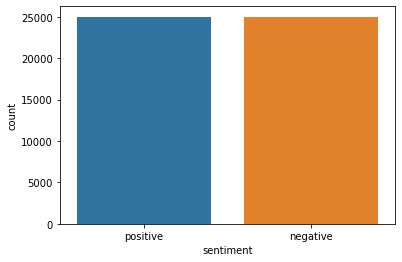

In [3]:
import seaborn as sns
sns.countplot(dataset.sentiment)

In [4]:
from bs4 import BeautifulSoup
import re
def cleanText(text):
    text = BeautifulSoup(text, "lxml").text
    text = re.sub(r'\|\|\|', r' ', text) 
    text = re.sub(r'http\S+', r'<URL>', text)
    text = text.lower()
    text = text.replace('x', '')
    return text

dataset['review'] = dataset['review'].apply(cleanText)
dataset

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive
...,...,...
49995,i thought this movie did a down right good job...,positive
49996,"bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,i am a catholic taught in parochial elementary...,negative
49998,i'm going to have to disagree with the previou...,negative


In [5]:
corpus = []
from nltk.tokenize import word_tokenize
for text in dataset['review']:
    words = [word.lower() for word in word_tokenize(text)] 
    corpus.append(words)
    
num_words = len(corpus)


In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
training_reviews,testing_reviews,training_labels,testing_labels  = train_test_split(dataset['review'].values,dataset['sentiment'].values,test_size = 0.2)
training_labels = le.fit_transform(training_labels)
testing_labels = le.fit_transform(testing_labels)

In [7]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=10000,oov_token='<OOV>')
tokenizer.fit_on_texts(training_reviews)
word_index = tokenizer.word_index
training_sequence = tokenizer.texts_to_sequences(training_reviews)
testing_sequence = tokenizer.texts_to_sequences(testing_reviews)
train_pad_sequence = pad_sequences(training_sequence,maxlen = 200,truncating= 'post',padding = 'pre')
test_pad_sequence = pad_sequences(testing_sequence,maxlen = 200,truncating= 'post',padding = 'pre')
print('Found unique tokens: {}'.format(len(word_index)))

Found unique tokens: 113935


In [8]:
embedded_words = {}
with open('glove.6B.200d.txt', encoding="utf8") as file:
    for line in file:
        words, coeff = line.split(maxsplit=1)
        coeff = np.array(coeff.split(),dtype = float)
        embedded_words[words] = coeff

In [9]:
embedding_matrix = np.zeros((len(word_index) + 1,200))
for word, i in word_index.items():
    embedding_vector = embedded_words.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

In [10]:
import tensorflow as tf

model = tf.keras.Sequential([tf.keras.layers.Embedding(len(word_index) + 1,200,weights=[embedding_matrix],input_length=200,
                            trainable=False),
                             tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
                             tf.keras.layers.Dropout(0.5),
                             tf.keras.layers.Dense(256,activation = 'relu',),
                             tf.keras.layers.Dense(128,activation = 'relu'),
                             tf.keras.layers.Dropout(0.5),
                             tf.keras.layers.Dense(1,activation = tf.nn.sigmoid)])
model.summary()


Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, 200, 200)          22787200  
_________________________________________________________________
bidirectional (Bidirectional (None, 128)               135680    
_________________________________________________________________
dropout (Dropout)            (None, 128)               0         
_________________________________________________________________
dense (Dense)                (None, 256)               33024     
_________________________________________________________________
dense_1 (Dense)              (None, 128)               32896     
_________________________________________________________________
dropout_1 (Dropout)          (None, 128)               0         
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 1

In [11]:
model.compile(loss = tf.keras.losses.BinaryCrossentropy() , optimizer='Adam' , metrics = 'accuracy')
history = model.fit(train_pad_sequence,training_labels,epochs = 30 ,validation_data=(test_pad_sequence,testing_labels))

Epoch 1/30
1250/1250 [==============================] - 199s 159ms/step - loss: 0.4969 - accuracy: 0.7573 - val_loss: 0.3762 - val_accuracy: 0.8338
Epoch 2/30
1250/1250 [==============================] - 191s 153ms/step - loss: 0.3620 - accuracy: 0.8454 - val_loss: 0.3501 - val_accuracy: 0.8502
Epoch 3/30
1250/1250 [==============================] - 193s 154ms/step - loss: 0.3270 - accuracy: 0.8645 - val_loss: 0.3281 - val_accuracy: 0.8602
Epoch 4/30
1250/1250 [==============================] - 198s 159ms/step - loss: 0.2997 - accuracy: 0.8735 - val_loss: 0.3269 - val_accuracy: 0.8592
Epoch 5/30
1250/1250 [==============================] - 228s 182ms/step - loss: 0.2794 - accuracy: 0.8847 - val_loss: 0.3140 - val_accuracy: 0.8623
Epoch 6/30
1250/1250 [==============================] - 223s 179ms/step - loss: 0.2563 - accuracy: 0.8949 - val_loss: 0.3188 - val_accuracy: 0.8686
Epoch 7/30
1250/1250 [==============================] - 226s 181ms/step - loss: 0.2385 - accuracy: 0.9034 - val_

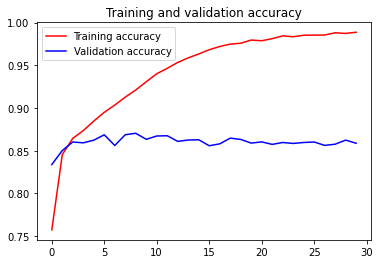

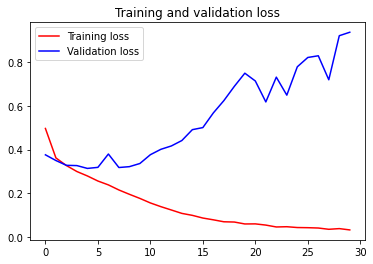

In [12]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend(loc=0)
plt.figure()

plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend(loc=0)

plt.show()

In [13]:
print('Training Accuracy: {}'.format(max(acc)))
print('Validation Accuracy: {}'.format(max(val_acc)))

Training Accuracy: 0.9886500239372253
Validation Accuracy: 0.8704000115394592


In [122]:
def get_result(txt):
    seq = tokenizer.texts_to_sequences(txt)
    padded = pad_sequences(seq, maxlen=200, dtype='int32', value=0)
    pred = model.predict(padded)
    print(pred)
    labels = [0,1]
    result = labels[round(pred[0][0])]
    result_dict = {0: 'negative', 1: 'positive'}
    print(result)
    return result_dict[result]


In [123]:
m = "This movie was not good at all. It had some good parts like the acting was pretty good but the story was not impressing at all."
get_result([m])

0


'negative'

In [124]:
m = "I can watch this movie forever just because of the beauty in its cinematography."
get_result([m])

1


'positive'

In [125]:
import tweepy as tw
from tweepy import OAuthHandler

consumer_key = 'r0kB0712EEOZT3jcVS7t74rfV'
consumer_secret = 'LIVOMWnwm47bpDnk0QjkuAmmY6QgO98P3vBhggEUhtM2Y4dTPo'
access_token = '1051487401451900928-czLgwZmGKlEyiZ33VorWXgeewRgPg8'
access_token_secret = 'JBCjSS6Ee8OW3qlDX2HTTI5ot2fX3lwjqlziLuJ4vdL8j'

In [126]:
try:
    auth = tw.OAuthHandler(consumer_key, consumer_secret)
    auth.set_access_token(access_token, access_token_secret)
    api = tw.API(auth)
except:
    print("Error: Authentication Failed")

In [127]:
def percentage(part,whole):
    return 100 * float(part)/float(whole)

In [128]:
def isEnglish(text):
    try:
        text.encode(encoding='utf-8').decode('ascii')
    except UnicodeDecodeError:
        return False
    else:
        return True

In [129]:
from datetime import datetime, timedelta

now = datetime.today().now()
prev=now-timedelta(days=1)
now=now.strftime("%Y-%m-%d")
prev=prev.strftime("%Y-%m-%d")
prev

'2021-06-17'

In [130]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    
    text.lower()
    # Remove urls
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    # Remove user @ references and '#' from tweet
    text = re.sub(r'\@\w+|\#','', text)
    # Remove punctuations
    #text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove stopwords
    text_tokens = word_tokenize(text)
    filtered_words = [w for w in text_tokens if not w in stop_words]
    
    #ps = PorterStemmer()
    #stemmed_words = [ps.stem(w) for w in filtered_words]
    #lemmatizer = WordNetLemmatizer()
    #lemma_words = [lemmatizer.lemmatize(w, pos='a') for w in stemmed_words]
    
    
    
    return " ".join(filtered_words)

In [131]:
def get_tweets(query, count):
    tweets = []
    query = query + " -filter:retweets"
    
    try:
        fetched_tweets = tw.Cursor(api.search, 
                                   q = query, 
                                   lang = 'en',
                                  since = prev,
                                  until = now).items(count)
        #api.search(q = query, count = count, lang = 'en')
        
        for tweet in fetched_tweets:
            parsed_tweet = {}
            print(tweet.text)
            if isEnglish(tweet.text) == True:
                parsed_tweet['text'] = preprocess_text(tweet.text)
                parsed_tweet['sentiment'] = get_result([preprocess_text(tweet.text)])
            
                if tweet.retweet_count > 0:
                    if parsed_tweet not in tweets:
                        tweets.append(parsed_tweet)
                    
                else:
                    tweets.append(parsed_tweet)
                
        return tweets
    
    except tw.TweepError as e:
        print("Error : " + str(e))
        

In [133]:
key = "#" + input ("Enter key or hashtag to search about: ")
numberOfTweets = int(input("Enter how many tweets to analyze: "))

Enter key or hashtag to search about: tenet
Enter how many tweets to analyze: 100


In [134]:
tweets = get_tweets(key, numberOfTweets)
pzt_tweets = [tweet for tweet in tweets if tweet['sentiment'] == 'positive']
neg_tweets = [tweet for tweet in tweets if tweet['sentiment'] == 'negative']

Opinion: Every movie should move at a pace similar to that of Tenet’s. 

I liked that I didn’t have to press forwar… https://t.co/RGtFROnntt
“We Live In A Twilight World." 

#TeneT
First 70mm print of #tenet struck from the camera neg 😲🎞️📽️ https://t.co/QM9D7Pc7TY
#Tenet (2020) #RobertPattinson
Ludwig Göransson: And then the third stage, which was when he came back and started… https://t.co/1mlRZCDHmm
#Tenet (2020) #RobertPattinson
audience review
If one wants to study Nolanisms, Tenet is the way to go. The movie i… https://t.co/BvSds7RRIG
@am_cinematheque Please add more showings 🥺🥺#NolanFans #TeneT https://t.co/1KbJat5RZr
#Tenet (2020) #RobertPattinson
audience review
I loved the movie so much I rewatched it 18,000 times and I made my… https://t.co/GgA3rrhvJL
#Tenet (2020) #RobertPattinson
Dimple Kapadia: I’ve never worked with anybody with this kind of passion, and dedica… https://t.co/uyiNtARKLk
#Tenet (2020) #RobertPattinson
John David Washington: I’m still learning, to be honest.

In [135]:
pzt_tweets

[{'text': 'A $ 1.1 billion deal made Dallas-Fort Worth : Tenet Steward swap ownership hospitals showmethemoney',
  'sentiment': 'positive'},
 {'text': 'AD - From blog Archive : Cineworld 4DX Tenet Review cineworld 4dx tenet',
  'sentiment': 'positive'},
 {'text': 'Watching . The last movie I saw big screen one worthy stage ... Tenet',
  'sentiment': 'positive'},
 {'text': 'Jazz coach look like villain movie Tenet', 'sentiment': 'positive'},
 {'text': 'tenet trip ...', 'sentiment': 'positive'}]

In [136]:
neg_tweets

[{'text': 'Imagine ate inverted food ! It would reverse cook inside stomach surely kill ! tenet',
  'sentiment': 'negative'},
 {'text': 'Tenet ( 2020 ) - Watch Online Trailers & amp ; Movie Clips : Tenet',
  'sentiment': 'negative'}]

In [137]:
print("Positive tweets percentage: {} %".format(percentage(len(pzt_tweets),len(tweets))))
print("Negative tweets percentage: {} %".format(percentage(len(neg_tweets),len(tweets))))

Positive tweets percentage: 71.42857142857143 %
Negative tweets percentage: 28.571428571428573 %


In [138]:
positive_p = percentage(len(pzt_tweets),len(tweets))
negative_p = percentage(len(neg_tweets),len(tweets))

positive_p = format(positive_p,'.2f')
negative_p = format(negative_p,'.2f')

print("Positive tweets percentage:  %" + positive_p)
print("Negative tweets percentage:  %" + negative_p)

Positive tweets percentage:  %71.43
Negative tweets percentage:  %28.57


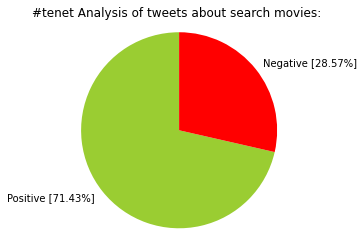

In [139]:
labels = ['Positive ['+str(positive_p)+'%]', 'Negative ['+str(negative_p)+'%]']
sizes = [positive_p, negative_p]
colors = ['yellowgreen','red']
fig, ax = plt.subplots()
ax.pie(sizes,labels=labels,startangle=90,colors=colors)
plt.title(key + " " + "Analysis of tweets about search movies: ")
ax.axis('equal')

plt.show()